In [8]:
import pandas as pd
import numpy as np
from google.colab import files
uploaded = files.upload()



Saving StudentPerformanceFactors.csv to StudentPerformanceFactors.csv


In [9]:
data=pd.read_csv("/content/StudentPerformanceFactors.csv")


In [ ]:
data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


Final *Grade*

In [10]:
data['Exam_Score'].describe()

,Exam_Score
count,6607.000000
mean,67.235659
std,3.890456
min,55.000000
25%,65.000000
50%,67.000000
75%,69.000000
max,101.000000


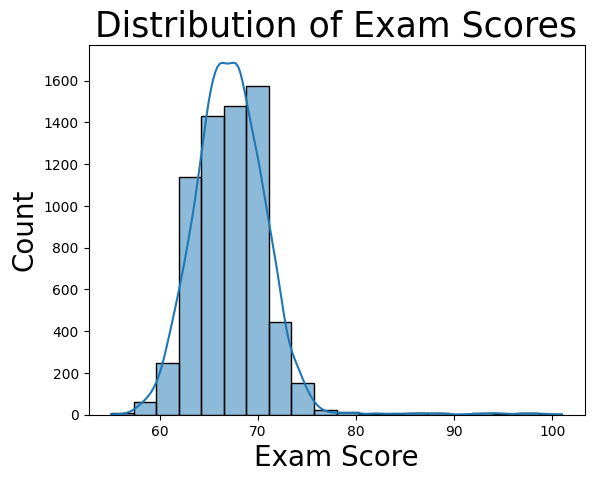

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data['Exam_Score'], bins=20, kde=True)
plt.title('Distribution of Exam Scores', fontsize=25)
plt.xlabel('Exam Score', fontsize=20)
plt.ylabel('Count', fontsize=20)
plt.show()



In [ ]:
data.columns


Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [ ]:
data.shape

(6607, 20)

In [ ]:
data.isnull().any()

,0
Hours_Studied,False
Attendance,False
Parental_Involvement,False
Access_to_Resources,False
Extracurricular_Activities,False
Sleep_Hours,False
Previous_Scores,False
Motivation_Level,False
Internet_Access,False
Tutoring_Sessions,False


In [ ]:
cols_to_fix = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']
print(data[cols_to_fix].dtypes)
for c in cols_to_fix:
    print(c, data[c].astype(str).unique()[:10])


Teacher_Quality             object
Parental_Education_Level    object
Distance_from_Home          object
dtype: object
Teacher_Quality ['Medium' 'High' 'Low' 'nan']
Parental_Education_Level ['High School' 'College' 'Postgraduate' 'nan']
Distance_from_Home ['Near' 'Moderate' 'Far' 'nan']


In [ ]:
cols = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']

# fill NaNs with the mode (most frequent) per column
for c in cols:
    mode_val = data[c].mode(dropna=True).iloc[0]
    data[c] = data[c].fillna(mode_val)



In [ ]:
cols_to_fix = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']

# Replace any True, 'True', or 'true' with False
for c in cols_to_fix:
    data[c] = data[c].apply(
        lambda x: False if str(x).strip().lower() == 'true' or x is True else x
    )


In [ ]:
for c in cols_to_fix:
    print(c, data[c].unique())


Teacher_Quality ['Medium' 'High' 'Low']
Parental_Education_Level ['High School' 'College' 'Postgraduate']
Distance_from_Home ['Near' 'Moderate' 'Far']


In [ ]:
data.isnull().any()

,0
Hours_Studied,False
Attendance,False
Parental_Involvement,False
Access_to_Resources,False
Extracurricular_Activities,False
Sleep_Hours,False
Previous_Scores,False
Motivation_Level,False
Internet_Access,False
Tutoring_Sessions,False


In [ ]:
male_student = len(data[data['Gender'] == 'Male'])
female_student = len(data[data['Gender'] == 'Female'])

print('Number of male students:', male_student)
print('Number of female students:', female_student)


Number of male students: 3814
Number of female students: 2793


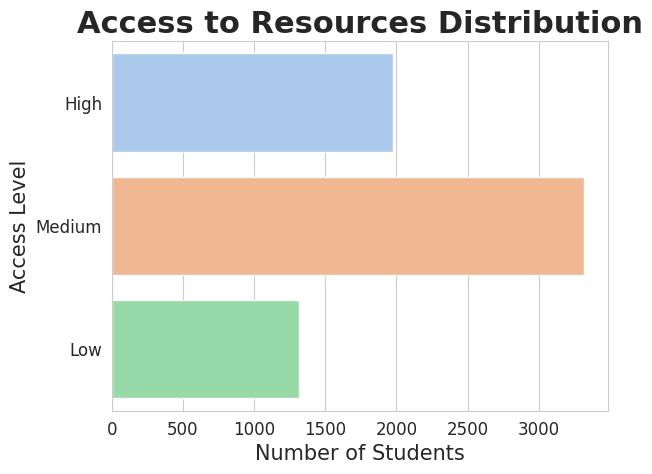

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
b = sns.countplot(y='Access_to_Resources', data=data, hue='Access_to_Resources',
                  palette='pastel', legend=False)
b.set_title('Access to Resources Distribution', fontsize=22, fontweight='bold')
b.set_xlabel('Number of Students', fontsize=15)
b.set_ylabel('Access Level', fontsize=15)
b.tick_params(axis='x', labelsize=12)
b.tick_params(axis='y', labelsize=12)
plt.show()




In [ ]:

participate_count = len(data[data['Extracurricular_Activities'].str.lower() == 'yes'])
not_participate_count = len(data[data['Extracurricular_Activities'].str.lower() == 'no'])

print("Number of students in extracurricular activities:", participate_count)
print("Number of students not in extracurricular activities:", not_participate_count)


Number of students in extracurricular activities: 3938
Number of students not in extracurricular activities: 2669


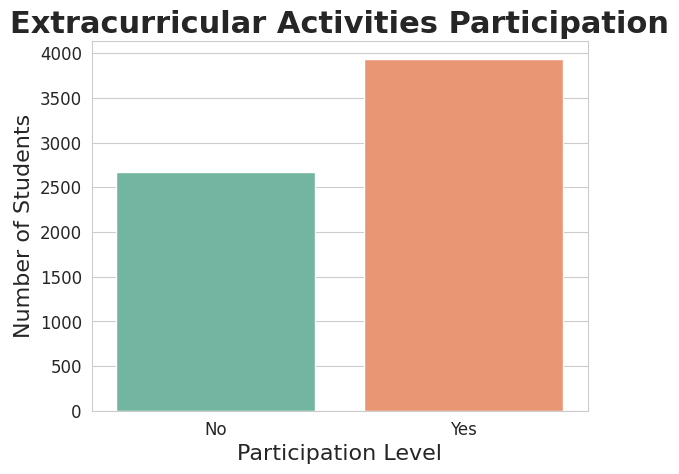

In [ ]:
b = sns.countplot(x='Extracurricular_Activities', data=data, hue='Extracurricular_Activities', palette='Set2', legend=False)
b.set_title('Extracurricular Activities Participation', fontsize=22, fontweight='bold')
b.set_xlabel('Participation Level', fontsize=16)
b.set_ylabel('Number of Students', fontsize=16)

b.tick_params(axis='x', labelsize=12)
b.tick_params(axis='y', labelsize=12)
plt.show()

In [ ]:
def grade_category(score):
    if score >= 90:
        return 'A'
    elif score >= 70:
        return 'B'
    else:
        return 'C'

data['Grade'] = data['Exam_Score'].apply(grade_category)


In [ ]:
print(data['Grade'].value_counts())


Grade
C    4982
B    1603
A      22
Name: count, dtype: int64


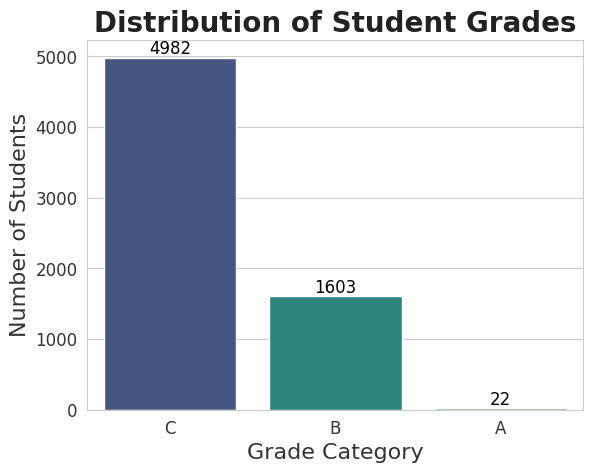

In [ ]:
sns.set_style('whitegrid')

b = sns.countplot(
    x='Grade',
    data=data,
    hue='Grade',
    palette='viridis',
    legend=False
)

b.set_title('Distribution of Student Grades', fontsize=20, fontweight='bold', color='#222222')
b.set_xlabel('Grade Category', fontsize=16, color='#333333')
b.set_ylabel('Number of Students', fontsize=16, color='#333333')

for p in b.patches:
    height = p.get_height()
    b.text(
        p.get_x() + p.get_width() / 2,
        height + 50,
        f'{int(height)}',
        ha='center',
        fontsize=12,
        color='black'
    )
b.tick_params(axis='x', labelsize=12, colors='#333333')
b.tick_params(axis='y', labelsize=12, colors='#333333')

plt.show()

In [ ]:
data = data.drop(['Gender', 'School_Type', 'Distance_from_Home', 'Learning_Disabilities'], axis=1)


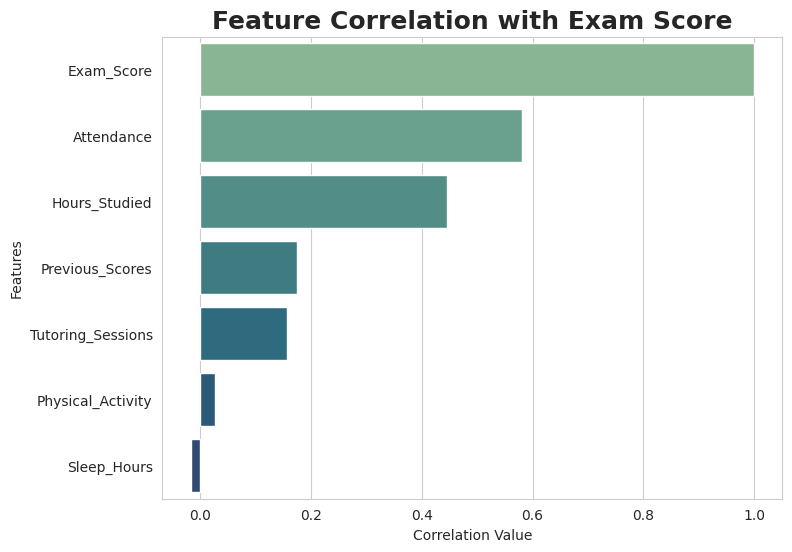

In [ ]:

corr = data.corr(numeric_only=True)['Exam_Score'].sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=corr.values, y=corr.index, hue=corr.index, palette='crest', dodge=False, legend=False)
plt.title('Feature Correlation with Exam Score', fontsize=18, fontweight='bold')
plt.xlabel('Correlation Value')
plt.ylabel('Features')
plt.show()

In [ ]:
low_corr_features = corr[abs(corr) < 0.05].index
print("Dropping low-correlation features:", list(low_corr_features))

data = data.drop(columns=low_corr_features)


Dropping low-correlation features: ['Physical_Activity', 'Sleep_Hours']


In [ ]:
print("Remaining columns after feature selection:")
print(data.columns)


Remaining columns after feature selection:
Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Previous_Scores',
       'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions',
       'Family_Income', 'Teacher_Quality', 'Peer_Influence',
       'Parental_Education_Level', 'Exam_Score', 'Grade'],
      dtype='object')


In [ ]:
data.dtypes


,0
Hours_Studied,int64
Attendance,int64
Parental_Involvement,object
Access_to_Resources,object
Extracurricular_Activities,object
Previous_Scores,int64
Motivation_Level,object
Internet_Access,object
Tutoring_Sessions,int64
Family_Income,object


In [ ]:
obj_cols = data.select_dtypes('object').columns
for c in obj_cols:
    data[c] = (
        data[c]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({'nan': np.nan})
    )


data = data.drop(columns=['Grade'], errors='ignore')


bin_cols = ['Access_to_Resources', 'Extracurricular_Activities', 'Internet_Access']
bin_map = {
    'yes': 1, 'y': 1, 'true': 1, '1': 1,
    'no': 0,  'n': 0, 'false': 0, '0': 0
}
for c in [col for col in bin_cols if col in data.columns]:
    data[c] = data[c].map(bin_map).astype('Int64')


ordinal_maps = {
    'Parental_Involvement':     {'low':0, 'medium':1, 'high':2},
    'Motivation_Level':         {'low':0, 'medium':1, 'high':2},
    'Family_Income':            {'low':0, 'middle':1, 'high':2},
    'Teacher_Quality':          {'poor':0, 'average':1, 'good':2, 'excellent':3},
    'Parental_Education_Level': {'primary':0, 'secondary':1, 'bachelor':2, 'master':3, 'phd':4},
}
for c, m in ordinal_maps.items():
    if c in data.columns:
        data[c] = data[c].map(m).astype('Int64')


for c in bin_cols + list(ordinal_maps.keys()):
    if c in data.columns and data[c].isna().any():
        mode_val = data[c].mode(dropna=True)
        if not mode_val.empty:
            data[c] = data[c].fillna(mode_val.iloc[0])


if 'Peer_Influence' in data.columns:
    data = pd.get_dummies(data, columns=['Peer_Influence'], drop_first=True)


print(data.dtypes)
print("Any non-numeric left? ->", data.select_dtypes(exclude=['number']).columns.tolist())


Hours_Studied                 int64
Attendance                    int64
Parental_Involvement          Int64
Access_to_Resources           Int64
Extracurricular_Activities    Int64
Previous_Scores               int64
Motivation_Level              Int64
Internet_Access               Int64
Tutoring_Sessions             int64
Family_Income                 Int64
Teacher_Quality               Int64
Parental_Education_Level      Int64
Exam_Score                    int64
Peer_Influence_neutral         bool
Peer_Influence_positive        bool
dtype: object
Any non-numeric left? -> ['Peer_Influence_neutral', 'Peer_Influence_positive']


In [ ]:

bool_cols = data.select_dtypes('bool').columns
for c in bool_cols:
    data[c] = data[c].astype(int)

print(data.dtypes)
print("Any non-numeric left? ->", data.select_dtypes(exclude=['number']).columns.tolist())


Hours_Studied                 int64
Attendance                    int64
Parental_Involvement          Int64
Access_to_Resources           Int64
Extracurricular_Activities    Int64
Previous_Scores               int64
Motivation_Level              Int64
Internet_Access               Int64
Tutoring_Sessions             int64
Family_Income                 Int64
Teacher_Quality               Int64
Parental_Education_Level      Int64
Exam_Score                    int64
Peer_Influence_neutral        int64
Peer_Influence_positive       int64
dtype: object
Any non-numeric left? -> []


In [ ]:
X = data.drop(columns=['Exam_Score'])
y = data['Exam_Score']


In [ ]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='median')
X_train = imp.fit_transform(X_train)
X_test  = imp.transform(X_test)

model = LinearRegression()
model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Access_to_Resources' 'Teacher_Quality' 'Parental_Education_Level']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Access_to_Resources' 'Teacher_Quality' 'Parental_Education_Level']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


LinearRegression()

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))


R² Score: 0.7048067197709244
Mean Absolute Error: 0.9686608705686341
Root Mean Squared Error: 2.042689014411407


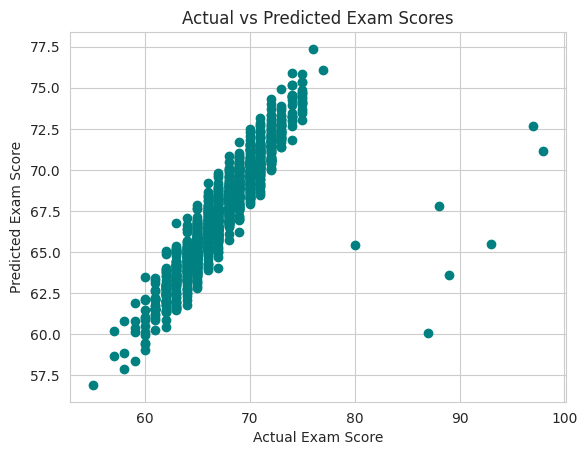

In [ ]:
plt.scatter(y_test, y_pred, color='teal')
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")
plt.show()

In [ ]:
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


X = data.drop(columns=['Exam_Score'])
y = data['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
def eval_model(model, Xtr, Xte, ytr, yte, name=""):
    model.fit(Xtr, ytr)
    p_tr = model.predict(Xtr)
    p_te = model.predict(Xte)
    out = {
        "model": name,
        "R2_train": r2_score(ytr, p_tr),
        "R2_test": r2_score(yte, p_te),
        "MAE": mean_absolute_error(yte, p_te),
        "RMSE": np.sqrt(((yte - p_te)**2).mean()),
        "fitted_model": model
    }
    return out


lin_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('reg', LinearRegression())
])


In [ ]:
poly2_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('reg', Ridge(alpha=1.0, random_state=42))
])

In [ ]:
poly3_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('reg', Ridge(alpha=1.0, random_state=42))
])

In [ ]:
results = []
for name, pipe in [
    ("Linear", lin_pipe),
    ("Poly d=2 (Ridge)", poly2_pipe),
    ("Poly d=3 (Ridge)", poly3_pipe),
]:
    results.append(eval_model(pipe, X_train, X_test, y_train, y_test, name))

pd.DataFrame(results)[["model","R2_train","R2_test","MAE","RMSE"]]

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Access_to_Resources' 'Teacher_Quality' 'Parental_Education_Level']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Access_to_Resources' 'Teacher_Quality' 'Parental_Education_Level']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Access_to_Resources' 'Teacher_Quality' 'Parental_Education_Level']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any 

,model,R2_train,R2_test,MAE,RMSE
0,Linear,0.651268,0.704807,0.968661,2.042689
1,Poly d=2 (Ridge),0.655954,0.700552,0.991582,2.057357
2,Poly d=3 (Ridge),0.676987,0.674446,1.098593,2.145164


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
import joblib, json

X = data.drop(columns=['Exam_Score'])
y = data['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_model = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('reg', LinearRegression())
])
best_model.fit(X_train, y_train)

joblib.dump(best_model, "best_model.pkl")
with open("feature_order.json","w") as f:
    json.dump({"features": X.columns.tolist()}, f)

print("Saved best_model.pkl and feature_order.json")


Saved best_model.pkl and feature_order.json


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Access_to_Resources' 'Teacher_Quality' 'Parental_Education_Level']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [ ]:
from google.colab import files
files.download("best_model.pkl")
files.download("feature_order.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!cp best_model.pkl /content/drive/MyDrive/
!cp feature_order.json /content/drive/MyDrive/


Mounted at /content/drive
